In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# Set premium aesthetics
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)


In [4]:
# Load the dataset
df = pd.read_csv('train.csv', sep='\t')
print(" Dataset Preview:")
print(df.head())

# Independent variables (X)
X = df[['GrLivArea', 'BedroomAbvGr', 'FullBath']]

# Dependent variable (y)
y = df['SalePrice']

 Dataset Preview:
   Id  MSSubClass MSZoning  LotFrontage  LotArea Street Alley LotShape  \
0   1          60       RL         65.0     8450   Pave   NaN      Reg   
1   2          20       RL         80.0     9600   Pave   NaN      Reg   
2   3          60       RL         68.0    11250   Pave   NaN      IR1   
3   4          70       RL         60.0     9550   Pave   NaN      IR1   
4   5          60       RL         84.0    14260   Pave   NaN      IR1   

  LandContour Utilities  ... PoolArea PoolQC Fence MiscFeature MiscVal MoSold  \
0         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      2   
1         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      5   
2         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      9   
3         Lvl    AllPub  ...        0    NaN   NaN         NaN       0      2   
4         Lvl    AllPub  ...        0    NaN   NaN         NaN       0     12   

  YrSold  SaleType  SaleCondition  SalePrice  
0  

In [10]:
# Initialize and Train the Multiple Regression Model
model = LinearRegression()
model.fit(X, y)

print("✅ Multiple Regression model trained successfully.")
print(f"\nCoefficients (GrLivArea, BedroomAbvGr, FullBath): {model.coef_}")
print(f"Intercept: {model.intercept_:.4f}")


✅ Multiple Regression model trained successfully.

Coefficients (GrLivArea, BedroomAbvGr, FullBath): [   110.06172639 -27859.33222353  29694.68839062]
Intercept: 47509.4822


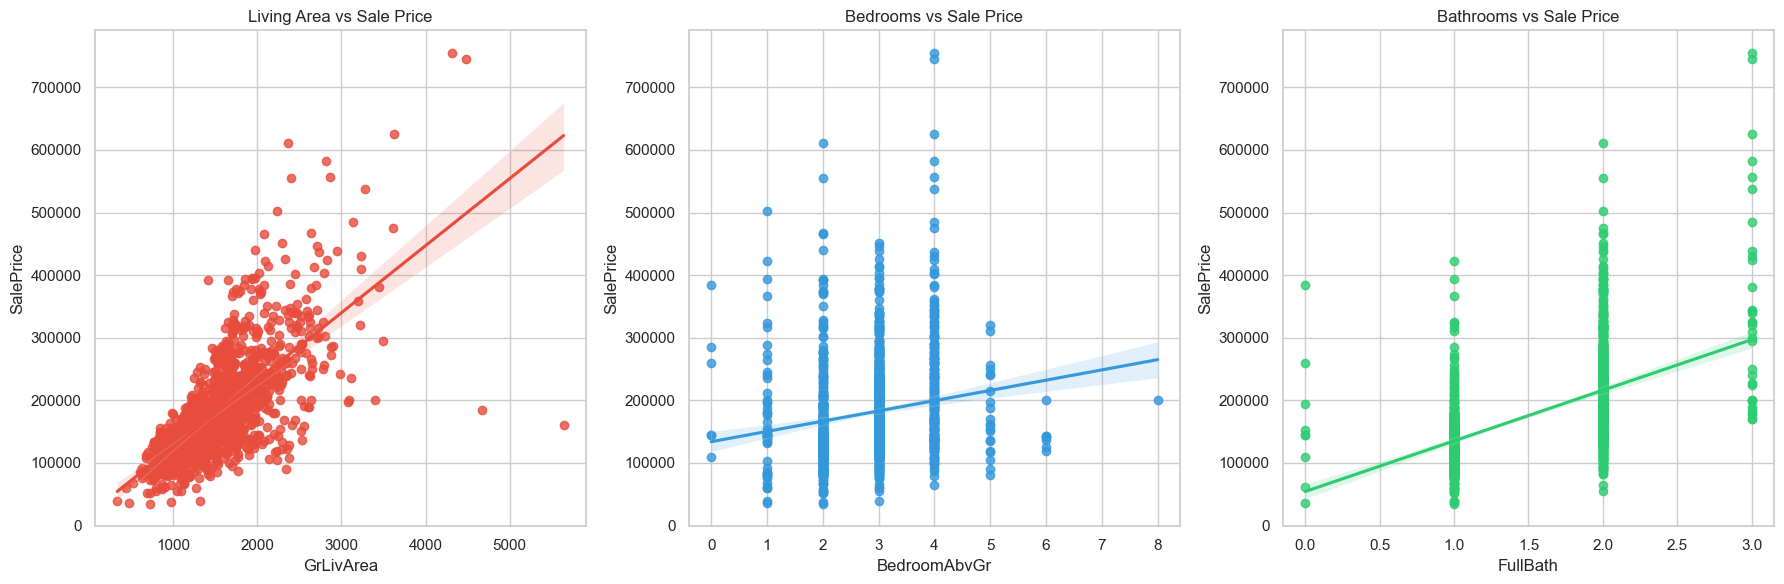

In [11]:
# Visualize relationships
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 6))

sns.regplot(x='GrLivArea',    y='SalePrice', data=df, ax=ax1, color='#e74c3c')
ax1.set_title('Living Area vs Sale Price')

sns.regplot(x='BedroomAbvGr', y='SalePrice', data=df, ax=ax2, color='#3498db')
ax2.set_title('Bedrooms vs Sale Price')

sns.regplot(x='FullBath',     y='SalePrice', data=df, ax=ax3, color='#2ecc71')
ax3.set_title('Bathrooms vs Sale Price')

plt.tight_layout()
plt.show()

In [12]:
# Custom Prediction with User Input
def predict_price(area, bedrooms, bathrooms):
    prediction = model.predict([[area, bedrooms, bathrooms]])[0]
    print(f"\n🔮 Predicted House Price:")
    print(f"   Living Area  : {area} sq ft")
    print(f"   Bedrooms     : {bedrooms}")
    print(f"   Bathrooms    : {bathrooms}")
    print(f"   💰 Estimated Sale Price : ${prediction:,.2f}")

try:
    u_area  = float(input("Enter living area (sq ft): "))
    u_beds  = float(input("Enter number of bedrooms: "))
    u_baths = float(input("Enter number of bathrooms: "))
    predict_price(u_area, u_beds, u_baths)
except ValueError:
    print("❌ Please enter numeric values.")


🔮 Predicted House Price:
   Living Area  : 14.0 sq ft
   Bedrooms     : 3.0
   Bathrooms    : 3.0
   💰 Estimated Sale Price : $54,556.41


c:\Users\aryan\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
